In [1]:
# Mount Google Drive - all progress saved here
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

# Create a project folder in your Google Drive
project_path = '/content/drive/MyDrive/DataQuest2026'
os.makedirs(project_path, exist_ok=True)

print(f"Project folder ready at: {project_path}")

Project folder ready at: /content/drive/MyDrive/DataQuest2026


In [4]:
from google.colab import files

# This will open a file picker - select both CSV files from your flash drive
uploaded = files.upload()

Saving Aerial_Waterfowl_Survey_Data_20260319.csv to Aerial_Waterfowl_Survey_Data_20260319.csv
Saving Snow_Goose_Poultry_Farm_dataset.csv to Snow_Goose_Poultry_Farm_dataset.csv


In [5]:
import shutil

# Move uploaded files to Google Drive permanently
for filename in uploaded.keys():
    src = f'/content/{filename}'
    dst = f'{project_path}/{filename}'
    shutil.copy(src, dst)
    print(f"Saved: {filename} → Google Drive ✅")

Saved: Aerial_Waterfowl_Survey_Data_20260319.csv → Google Drive ✅
Saved: Snow_Goose_Poultry_Farm_dataset.csv → Google Drive ✅


In [6]:
# Check all files are in Drive
files_in_drive = os.listdir(project_path)
print("Files in your DataQuest folder:")
for f in files_in_drive:
    print(f"  ✅ {f}")

Files in your DataQuest folder:
  ✅ Aerial_Waterfowl_Survey_Data_20260319.csv
  ✅ Snow_Goose_Poultry_Farm_dataset.csv


In [8]:
import os

# Check what's actually in your Drive folder
print("Files in DataQuest folder:")
for f in os.listdir(project_path):
    size = os.path.getsize(f'{project_path}/{f}')
    print(f"  {f} --> Size: {size/1024:.1f} KB")

Files in DataQuest folder:
  Aerial_Waterfowl_Survey_Data_20260319.csv --> Size: 0.1 KB
  Snow_Goose_Poultry_Farm_dataset.csv --> Size: 0.1 KB


# Working with the data sets Below

In [9]:
import pandas as pd


# Just re-run this - files will be there now!
df_goose = pd.read_csv(f'{project_path}/Snow_Goose_Poultry_Farm_dataset.csv')
df_aerial = pd.read_csv(f'{project_path}/Aerial_Waterfowl_Survey_Data_20260319.csv')

print(f"Snow Goose dataset: {df_goose.shape}")
print(f"Aerial Survey dataset: {df_aerial.shape}")

Snow Goose dataset: (630672, 32)
Aerial Survey dataset: (2173, 39)


# Getting a brief about the data

In [10]:
# Basic snapshot of both datasets

print("=" * 60)
print("SNOW GOOSE DATASET")
print("=" * 60)
print(f"\nShape: {df_goose.shape}")
print(f"\nColumns:\n{df_goose.columns.tolist()}")
print(f"\nMissing Values:\n{df_goose.isnull().sum()}")
print(f"\npoints_per_hr stats:\n{df_goose['points_per_hr'].describe()}")
print(f"\n% zeros in points_per_hr: {(df_goose['points_per_hr']==0).mean()*100:.1f}%")
print(f"\nDay/Night split:\n{df_goose['day_night'].value_counts()}")
print(f"\nWeek range: {df_goose['week'].min()} to {df_goose['week'].max()}")
print(f"\nTemp range: {df_goose['avg_temp'].min():.1f} to {df_goose['avg_temp'].max():.1f} C")

print("\n")
print("=" * 60)
print("AERIAL SURVEY DATASET")
print("=" * 60)
print(f"\nShape: {df_aerial.shape}")
print(f"\nColumns:\n{df_aerial.columns.tolist()}")
print(f"\nMissing Values:\n{df_aerial.isnull().sum()}")
print(f"\nFirst 5 rows:\n{df_aerial.head()}")
print(f"\nBasic stats:\n{df_aerial.describe()}")

SNOW GOOSE DATASET

Shape: (630672, 32)

Columns:
['Unnamed: 0', 'unique_id', 'points_per_hr', 'week', 'day_night', 'avg_temp', 'dcoast', 'dsewage', 'dwaterbody', 'dnwr', 'farm_pond_binary', 'adjacent_farms', 'open_water_2km', 'developed_2km', 'barren_2km', 'forest_2km', 'shrub_scrub_2km', 'grassland_2km', 'pasture_hay_2km', 'crops_2km', 'woody_wetlands_2km', 'emergent_wetlands_2km', 'open_water_20km', 'developed_20km', 'barren_20km', 'forest_20km', 'shrub_scrub_20km', 'grassland_20km', 'pasture_hay_20km', 'crops_20km', 'woody_wetlands_20km', 'emergent_wetlands_20km']

Missing Values:
Unnamed: 0                    0
unique_id                     0
points_per_hr             30032
week                          0
day_night                     0
avg_temp                      0
dcoast                        0
dsewage                       0
dwaterbody                    0
dnwr                          0
farm_pond_binary              0
adjacent_farms                0
open_water_2km          

---

## Dataset Overview

| Dataset | Rows | Columns |
|---|---|---|
| Snow Goose Poultry Farm Dataset | 630,672 | 32 |
| Aerial Waterfowl Survey Dataset | 2,173 | 39 |

---

## Finding 1 — Target Variable Confirmed 🎯

- `points_per_hr` contains **30,032 missing values** — these are the values to predict
- Remaining **600,640 rows** with known values will be used for model training

---

## Finding 2 — Zero Inflation Confirmed 🔥

- **93.8%** of all farm-week-period observations = zero goose exposure
- Only **6.2%** of farms show any goose activity at all
- Among non-zero farms, max exposure = **1,318.8 goose-points/hour**
- **Implication:** Standard regression models will fail here — a two-stage
  zero-inflated model is required (Stage 1: will geese show up? Stage 2: how many?)

---

## Finding 3 — Temperature Range 🌡️

- Temperature ranges from **-3.2°C to 18.8°C**
- Perfectly aligns with winter migration window (November–March)
- Temperature expected to be a key predictor of goose exposure

---

## Finding 4 — Aerial Survey Dataset 📅

- Data spans **1974 to 2026 — 52 years** of waterfowl survey data
- Contains counts for **38 bird species** across Delaware zones
- Will be used to show long-term Snow Goose population trends
- Provides broader ecological context to complement the GPS farm-level data

---

## Core Research Question

> *Which poultry farms on the Delmarva Peninsula face the highest risk of
> Snow Goose exposure — and what landscape, temporal, and environmental
> factors drive that risk?*

---

## Banking/Financial Angle (JPMC Connection)

This risk data has direct financial applications:

1. **Risk-adjusted agricultural lending** — high-exposure farms = higher
   HPAI outbreak probability = higher loan default risk
2. **Targeted biosecurity loan products** — timed to peak migration weeks
3. **Portfolio stress testing** — correlated default risk across farm clusters

---

# loading the libraries up

In [11]:
# Install extra libraries that don't come with Colab by default
# ruptures = finds exact changepoints in time series (migration weeks)
# shap = explains WHY our model makes each prediction
# pysal = spatial statistics (hot spot mapping)
!pip install ruptures shap pysal -q

# Now import everything we need
import pandas as pd           # data manipulation - like Excel but in Python
import numpy as np            # math operations on large arrays
import matplotlib.pyplot as plt  # basic plotting
import seaborn as sns         # prettier plots
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 64.0 MB/s eta 0:00:00
✅ All libraries ready!


# mounting to the drive again best option

In [12]:
# Always run this first - mounts your Google Drive
from google.colab import drive
drive.mount('/content/drive')

project_path = '/content/drive/MyDrive/DataQuest2026'

# Load both datasets from Drive
df_goose = pd.read_csv(f'{project_path}/Snow_Goose_Poultry_Farm_dataset.csv')
df_aerial = pd.read_csv(f'{project_path}/Aerial_Waterfowl_Survey_Data_20260319.csv')

print(f"✅ Snow Goose: {df_goose.shape}")
print(f"✅ Aerial Survey: {df_aerial.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Snow Goose: (630672, 32)
✅ Aerial Survey: (2173, 39)


# data cleaning

In [13]:
# Remove the unnamed index column - it's useless, just row numbers
df_goose = df_goose.drop(columns=['Unnamed: 0'])

# Separate rows WHERE we know points_per_hr (for training our model) KNOWN Values
# vs WHERE it's missing (these we need to PREDICT for Best Modeling award) NOT KNOWN values
df_known = df_goose[df_goose['points_per_hr'].notna()].copy()
df_missing = df_goose[df_goose['points_per_hr'].isna()].copy()

print(f"✅ Rows we know (training data): {len(df_known):,}")
print(f"✅ Rows to predict (competition target): {len(df_missing):,}")
print(f"\nday_night unique values: {df_goose['day_night'].unique()}") # figuring out when tis day and when its night
print(f"farm_pond unique values: {df_goose['farm_pond_binary'].unique()}") # is there a pond? yes or no

✅ Rows we know (training data): 600,640
✅ Rows to predict (competition target): 30,032

day_night unique values: ['night' 'day']
farm_pond unique values: ['yes' 'no']


# confirming the zero inflation

Zero exposure observations: 98.5%
Non-zero exposure observations: 1.5%

Among farms WITH goose exposure:
  Average: 64.978 geese/hr
  Maximum: 1318.8 geese/hr
  Top 1% starts at: 607.41 geese/hr


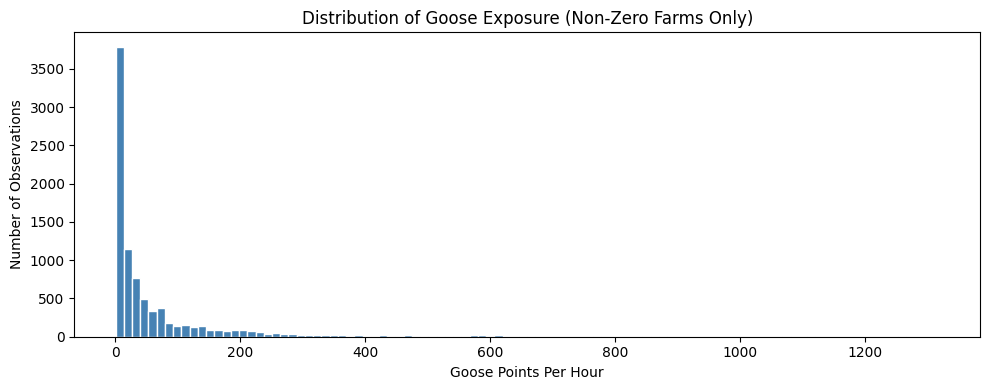

✅ Plot saved!


In [14]:
# Count how many rows have ZERO goose exposure
zero_pct = (df_known['points_per_hr'] == 0).mean() * 100

# Separate zero vs non-zero farms
df_zeros = df_known[df_known['points_per_hr'] == 0]
df_nonzero = df_known[df_known['points_per_hr'] > 0]

print(f"Zero exposure observations: {zero_pct:.1f}%")
print(f"Non-zero exposure observations: {100-zero_pct:.1f}%")
print(f"\nAmong farms WITH goose exposure:")
print(f"  Average: {df_nonzero['points_per_hr'].mean():.3f} geese/hr")
print(f"  Maximum: {df_nonzero['points_per_hr'].max():.1f} geese/hr")
print(f"  Top 1% starts at: {df_nonzero['points_per_hr'].quantile(0.99):.2f} geese/hr")

# Plot the distribution of non-zero values only
plt.figure(figsize=(10, 4))
plt.hist(df_nonzero['points_per_hr'], bins=100, color='steelblue', edgecolor='white')
plt.title('Distribution of Goose Exposure (Non-Zero Farms Only)')
plt.xlabel('Goose Points Per Hour')
plt.ylabel('Number of Observations')
plt.tight_layout()
plt.savefig(f'{project_path}/plot_zero_inflation.png', dpi=150)
plt.show()
print("✅ Plot saved!")

# Weekely Migration pattern

Top 10 highest risk weeks:
    week  mean_exposure  max_exposure
4      5       2.998283   1118.220619
1      2       2.619688    851.908163
3      4       2.403992    873.773212
2      3       1.968017   1318.835571
19    52       1.739153   1256.533700
18    51       1.318214   1070.611434
6      7       1.184105    451.063637
5      6       1.182292    339.805825
0      1       1.034624    671.014683
7      8       0.792801    537.464311


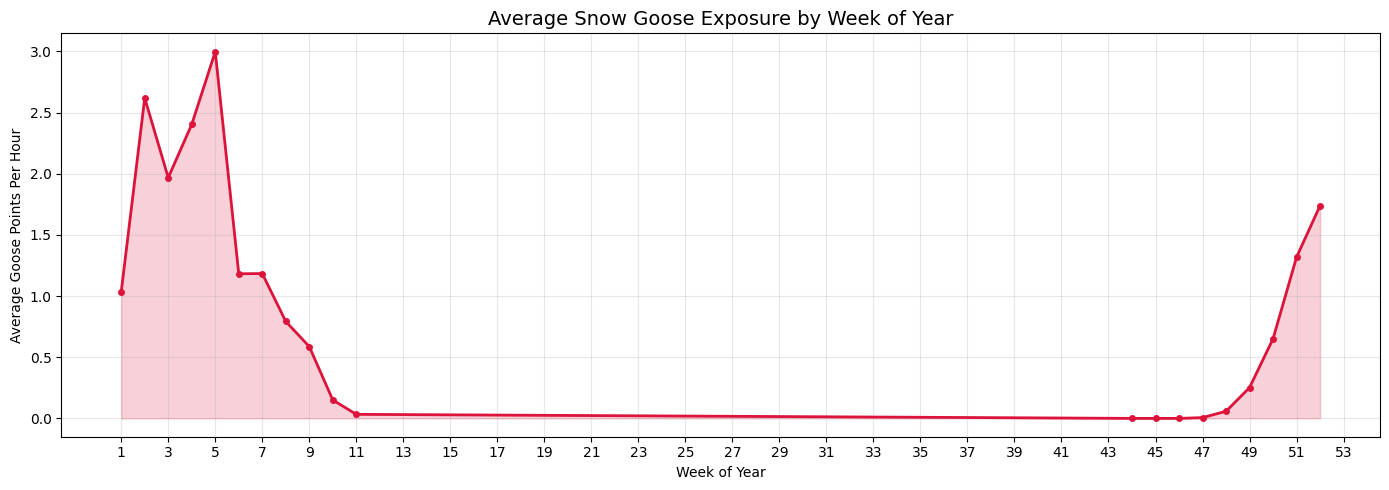

✅ Plot saved!


In [15]:
# Group by week - find average goose exposure each week of the year
# This tells us WHEN geese are most active near farms
weekly = df_known.groupby('week')['points_per_hr'].agg(
    mean_exposure='mean',
    max_exposure='max',
    nonzero_farms=lambda x: (x > 0).sum()
).reset_index()

print("Top 10 highest risk weeks:")
print(weekly.nlargest(10, 'mean_exposure')[['week','mean_exposure','max_exposure']].to_string())

# Plot weekly pattern
plt.figure(figsize=(14, 5))
plt.plot(weekly['week'], weekly['mean_exposure'],
         color='crimson', linewidth=2, marker='o', markersize=4)
plt.fill_between(weekly['week'], weekly['mean_exposure'], alpha=0.2, color='crimson')
plt.title('Average Snow Goose Exposure by Week of Year', fontsize=14)
plt.xlabel('Week of Year')
plt.ylabel('Average Goose Points Per Hour')
plt.xticks(range(1, 54, 2))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{project_path}/plot_weekly_migration.png', dpi=150)
plt.show()
print("✅ Plot saved!")

# What are the exact migration weeks in which they were moving

Changepoints detected at weeks: [5, 20]


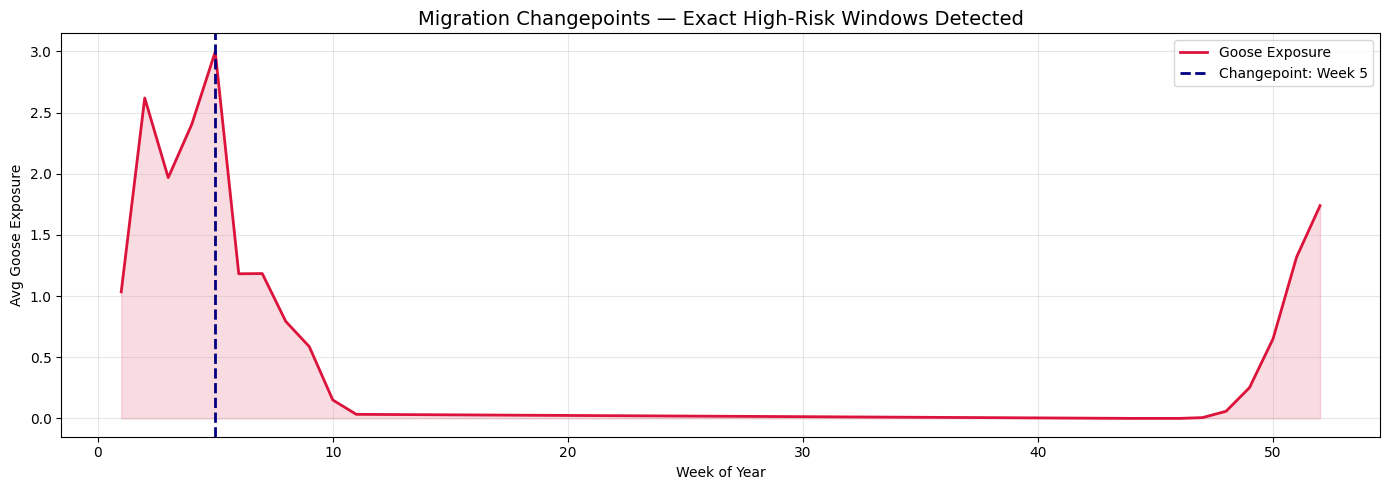

✅ Changepoint plot saved!


In [16]:
import ruptures as rpt

# Use the weekly average exposure values we just calculated
signal = weekly['mean_exposure'].values

# PELT algorithm - finds exact points where the pattern CHANGES
# pen=3 means "only flag a changepoint if it's a significant shift"
model = rpt.Pelt(model="rbf").fit(signal)
breakpoints = model.predict(pen=3)

print(f"Changepoints detected at weeks: {breakpoints}")

# Plot with changepoints marked
plt.figure(figsize=(14, 5))
plt.plot(weekly['week'], signal, color='crimson', linewidth=2, label='Goose Exposure')
plt.fill_between(weekly['week'], signal, alpha=0.15, color='crimson')

# Draw vertical lines at each changepoint
colors = ['navy', 'darkgreen', 'purple', 'orange']
for i, bp in enumerate(breakpoints[:-1]):  # last one is always end of data
    week_num = weekly['week'].iloc[bp-1]
    plt.axvline(x=week_num, color=colors[i % len(colors)],
                linestyle='--', linewidth=2,
                label=f'Changepoint: Week {week_num}')

plt.title('Migration Changepoints — Exact High-Risk Windows Detected', fontsize=14)
plt.xlabel('Week of Year')
plt.ylabel('Avg Goose Exposure')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{project_path}/plot_changepoints.png', dpi=150)
plt.show()
print("✅ Changepoint plot saved!")

# day/night and temperature analysis

Day vs Night Exposure:
             mean  median  nonzero_pct
day_night                             
day        1.0285     0.0       1.8946
night      0.8694     0.0       1.0262

Exposure by Temperature:
temp_bin
<0°C       5.88469
0-5°C      1.99663
5-10°C     0.45077
10-15°C    0.22031
15-20°C    0.00000
Name: points_per_hr, dtype: float64


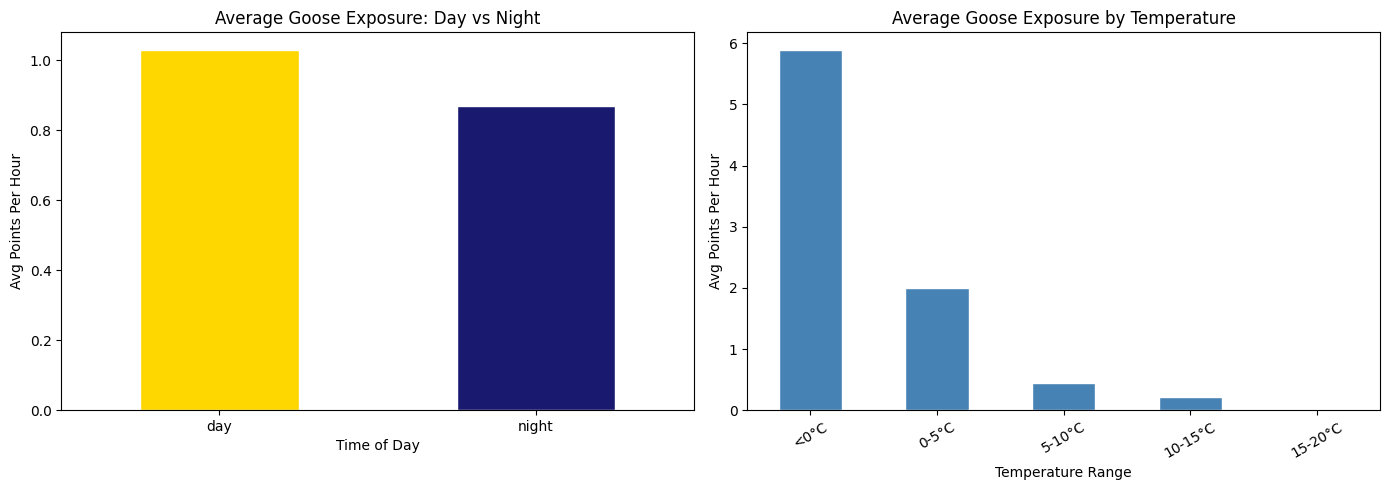

✅ Plot saved!


In [17]:
# DAY VS NIGHT
# Do geese visit farms more during day or night?
daynight = df_known.groupby('day_night')['points_per_hr'].agg(
    mean='mean',
    median='median',
    nonzero_pct=lambda x: (x > 0).mean() * 100
).round(4)
print("Day vs Night Exposure:")
print(daynight)

# TEMPERATURE BINS
# Does cold weather push geese closer to farms?
df_known['temp_bin'] = pd.cut(df_known['avg_temp'],
                               bins=[-5, 0, 5, 10, 15, 20],
                               labels=['<0°C','0-5°C','5-10°C','10-15°C','15-20°C'])

temp_effect = df_known.groupby('temp_bin')['points_per_hr'].mean().round(5)
print("\nExposure by Temperature:")
print(temp_effect)

# Plot both side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Day/Night bar chart
daynight['mean'].plot(kind='bar', ax=ax1, color=['gold','midnightblue'],
                       edgecolor='white', width=0.5)
ax1.set_title('Average Goose Exposure: Day vs Night')
ax1.set_xlabel('Time of Day')
ax1.set_ylabel('Avg Points Per Hour')
ax1.tick_params(axis='x', rotation=0)

# Temperature line chart
temp_effect.plot(kind='bar', ax=ax2, color='steelblue', edgecolor='white')
ax2.set_title('Average Goose Exposure by Temperature')
ax2.set_xlabel('Temperature Range')
ax2.set_ylabel('Avg Points Per Hour')
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(f'{project_path}/plot_daynight_temp.png', dpi=150)
plt.show()
print("✅ Plot saved!")

# 52 years Aerial survey trend

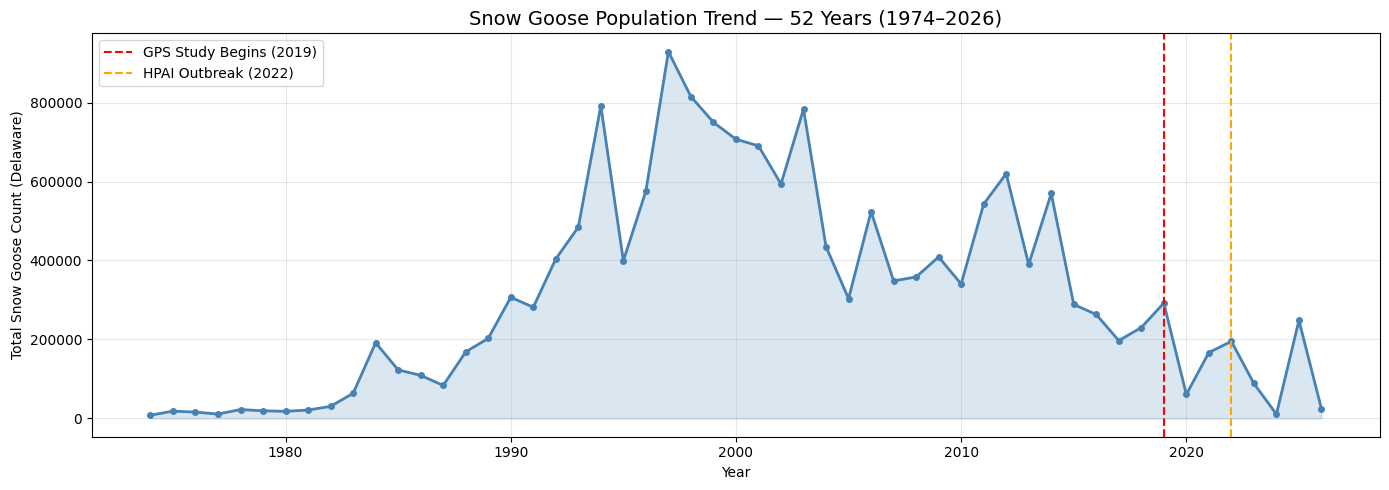

✅ 52-year trend plot saved!


In [18]:
# Clean Snow Goose counts - remove commas from numbers like "15,424"
df_aerial['Snow Goose'] = pd.to_numeric(
    df_aerial['Snow Goose'].astype(str).str.replace(',', ''),
    errors='coerce'
)

# Group by year - total Snow Goose count each year
yearly = df_aerial.groupby('Year')['Snow Goose'].sum().reset_index()

# Plot 52-year trend
plt.figure(figsize=(14, 5))
plt.plot(yearly['Year'], yearly['Snow Goose'],
         color='steelblue', linewidth=2, marker='o', markersize=4)
plt.fill_between(yearly['Year'], yearly['Snow Goose'], alpha=0.2, color='steelblue')
plt.title('Snow Goose Population Trend — 52 Years (1974–2026)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Total Snow Goose Count (Delaware)')
plt.axvline(x=2019, color='red', linestyle='--', linewidth=1.5, label='GPS Study Begins (2019)')
plt.axvline(x=2022, color='orange', linestyle='--', linewidth=1.5, label='HPAI Outbreak (2022)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{project_path}/plot_52yr_trend.png', dpi=150)
plt.show()
print("✅ 52-year trend plot saved!")

# Risk score for each farm that checks the risk of goose arriving to each farm

In [19]:
# ============================================
# Build a RISK SCORE for each unique farm
# This combines ALL the signals we found above
# Think of it like a credit score - but for Bird Flu risk
# ============================================

# Step 1 - Get farm-level average exposure
farm_stats = df_known.groupby('unique_id').agg(
    avg_exposure=('points_per_hr', 'mean'),
    max_exposure=('points_per_hr', 'max'),
    nonzero_weeks=('points_per_hr', lambda x: (x > 0).sum()),
    avg_temp=('avg_temp', 'mean'),
    dcoast=('dcoast', 'first'),
    dwaterbody=('dwaterbody', 'first'),
    dnwr=('dnwr', 'first'),
    adjacent_farms=('adjacent_farms', 'first'),
    farm_pond=('farm_pond_binary', 'first'),
    open_water_2km=('open_water_2km', 'first'),
    emergent_wetlands_2km=('emergent_wetlands_2km', 'first'),
    crops_2km=('crops_2km', 'first'),
).reset_index()

print(f"Total unique farms: {len(farm_stats):,}")
print(f"\nFarm exposure stats:")
print(farm_stats['avg_exposure'].describe().round(4))

Total unique farms: 3,504

Farm exposure stats:
count    3504.0000
mean        1.0167
std         4.9321
min         0.0000
25%         0.0000
50%         0.0000
75%         0.2069
max        80.3528
Name: avg_exposure, dtype: float64


# calculating risk score on the basis of 0-100 with 100 being the max

In [20]:
from sklearn.preprocessing import MinMaxScaler

# Each component gets normalized to 0-1 scale
# Then we combine them with weights based on our findings
# Higher weight = more important factor

scaler = MinMaxScaler()

# Normalize each risk factor to 0-1
farm_stats['norm_exposure']    = scaler.fit_transform(farm_stats[['avg_exposure']])
farm_stats['norm_max']         = scaler.fit_transform(farm_stats[['max_exposure']])
farm_stats['norm_weeks']       = scaler.fit_transform(farm_stats[['nonzero_weeks']])
farm_stats['norm_coast']       = 1 - scaler.fit_transform(farm_stats[['dcoast']])      # closer = riskier
farm_stats['norm_water']       = 1 - scaler.fit_transform(farm_stats[['dwaterbody']])  # closer = riskier
farm_stats['norm_adj_farms']   = scaler.fit_transform(farm_stats[['adjacent_farms']])  # more neighbors = riskier
farm_stats['norm_open_water']  = scaler.fit_transform(farm_stats[['open_water_2km']])  # more water = riskier
farm_stats['norm_wetlands']    = scaler.fit_transform(farm_stats[['emergent_wetlands_2km']])

# Weighted Risk Score - weights based on what our analysis showed matters most
farm_stats['risk_score'] = (
    farm_stats['norm_exposure']   * 0.30 +   # actual goose exposure - most important
    farm_stats['norm_max']        * 0.15 +   # peak exposure - worst case scenario
    farm_stats['norm_weeks']      * 0.15 +   # how many weeks exposed
    farm_stats['norm_coast']      * 0.10 +   # proximity to coast
    farm_stats['norm_water']      * 0.10 +   # proximity to water body
    farm_stats['norm_adj_farms']  * 0.10 +   # neighboring farm cluster risk
    farm_stats['norm_open_water'] * 0.05 +   # open water nearby
    farm_stats['norm_wetlands']   * 0.05     # wetlands nearby
) * 100  # scale to 0-100

# Assign risk categories - like credit ratings!
farm_stats['risk_category'] = pd.cut(
    farm_stats['risk_score'],
    bins=[0, 20, 40, 60, 80, 100],
    labels=['🟢 Very Low', '🟡 Low', '🟠 Medium', '🔴 High', '🚨 Critical']
)

print("Risk Score Distribution:")
print(farm_stats['risk_category'].value_counts().sort_index())
print(f"\nTop 10 highest risk farms:")
print(farm_stats.nlargest(10, 'risk_score')[['unique_id','risk_score','risk_category','avg_exposure','adjacent_farms']].to_string())

Risk Score Distribution:
risk_category
🟢 Very Low    2682
🟡 Low          770
🟠 Medium        39
🔴 High          13
🚨 Critical       0
Name: count, dtype: int64

Top 10 highest risk farms:
      unique_id  risk_score risk_category  avg_exposure  adjacent_farms
1783       3165   78.065903        🔴 High     80.352840              12
1782       3164   77.606749        🔴 High     79.064012              12
1558       2628   67.095126        🔴 High     51.760425               4
1556       2626   66.947879        🔴 High     51.980309               4
1557       2627   66.942974        🔴 High     51.951112               4
1555       2625   66.913580        🔴 High     51.938417               4
1781       3163   64.840668        🔴 High     60.172841              25
1780       3162   64.526910        🔴 High     59.520733              25
1779       3160   63.602283        🔴 High     57.204801              25
1778       3159   63.066025        🔴 High     56.455325              25


# graphing the risk score cell from above

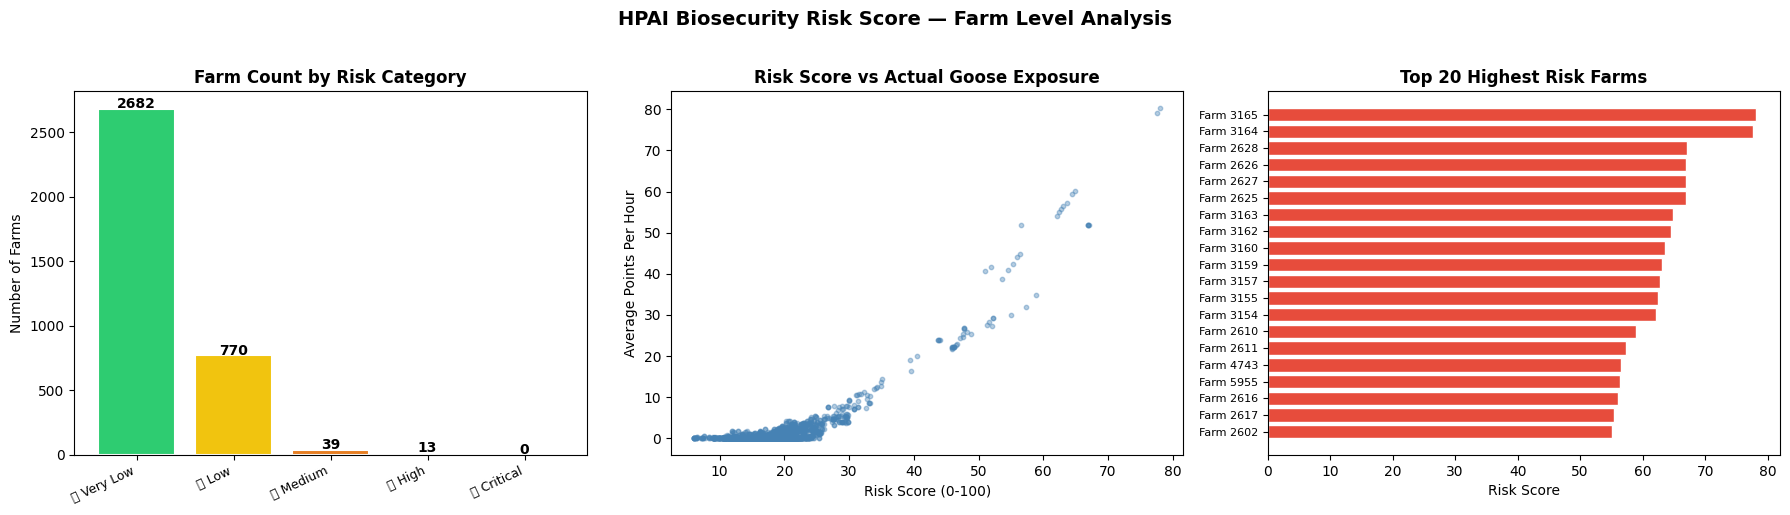

✅ Risk score plots saved!


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 - Risk score distribution
colors_map = {
    '🟢 Very Low': '#2ecc71',
    '🟡 Low': '#f1c40f',
    '🟠 Medium': '#e67e22',
    '🔴 High': '#e74c3c',
    '🚨 Critical': '#8e044b'
}
risk_counts = farm_stats['risk_category'].value_counts().sort_index()
bars = axes[0].bar(range(len(risk_counts)), risk_counts.values,
                   color=[colors_map[k] for k in risk_counts.index],
                   edgecolor='white', linewidth=1.5)
axes[0].set_xticks(range(len(risk_counts)))
axes[0].set_xticklabels(risk_counts.index, rotation=25, ha='right', fontsize=9)
axes[0].set_title('Farm Count by Risk Category', fontweight='bold')
axes[0].set_ylabel('Number of Farms')

# Add count labels on bars
for bar, val in zip(bars, risk_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', fontweight='bold', fontsize=10)

# Plot 2 - Risk score vs actual exposure
axes[1].scatter(farm_stats['risk_score'], farm_stats['avg_exposure'],
                alpha=0.4, color='steelblue', s=10)
axes[1].set_title('Risk Score vs Actual Goose Exposure', fontweight='bold')
axes[1].set_xlabel('Risk Score (0-100)')
axes[1].set_ylabel('Average Points Per Hour')

# Plot 3 - Top 20 riskiest farms
top20 = farm_stats.nlargest(20, 'risk_score')
axes[2].barh(range(20), top20['risk_score'].values, color='#e74c3c', edgecolor='white')
axes[2].set_yticks(range(20))
axes[2].set_yticklabels([f"Farm {i}" for i in top20['unique_id']], fontsize=8)
axes[2].set_title('Top 20 Highest Risk Farms', fontweight='bold')
axes[2].set_xlabel('Risk Score')
axes[2].invert_yaxis()

plt.suptitle('HPAI Biosecurity Risk Score — Farm Level Analysis',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{project_path}/plot_risk_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Risk score plots saved!")

# converting valyue to number for farm_pond_binary column

In [23]:
# Step 1 - Check what values are actually in these columns
print("farm_pond_binary values:", df_known['farm_pond_binary'].unique())
print("day_night values:", df_known['day_night'].unique())

# Step 2 - Convert ALL string/categorical columns to numbers
df_known['farm_pond_binary'] = df_known['farm_pond_binary'].map(
    {'yes': 1, 'no': 0, 1: 1, 2: 0}  # handles both string and number versions
)

# day_night already handled but let's make sure
df_known['day_night_num'] = df_known['day_night'].map(
    {'day': 1, 'night': 0}
)

# Step 3 - Rebuild X with clean data
feature_cols_clean = ['week', 'day_night_num', 'avg_temp', 'dcoast', 'dsewage',
                      'dwaterbody', 'dnwr', 'farm_pond_binary', 'adjacent_farms',
                      'open_water_2km', 'developed_2km', 'forest_2km',
                      'grassland_2km', 'pasture_hay_2km', 'crops_2km',
                      'woody_wetlands_2km', 'emergent_wetlands_2km',
                      'open_water_20km', 'crops_20km', 'woody_wetlands_20km',
                      'emergent_wetlands_20km']

X = df_known[feature_cols_clean].fillna(0)
y = df_known['points_per_hr']
y_binary = (y > 0).astype(int)

# Step 4 - Verify no more strings
print("\nData types check:")
print(X.dtypes)
print(f"\nAny nulls left: {X.isnull().sum().sum()}")
print(f"\n✅ X shape: {X.shape}")

farm_pond_binary values: ['yes' 'no']
day_night values: ['night' 'day']

Data types check:
week                        int64
day_night_num               int64
avg_temp                  float64
dcoast                    float64
dsewage                   float64
dwaterbody                float64
dnwr                      float64
farm_pond_binary            int64
adjacent_farms              int64
open_water_2km            float64
developed_2km             float64
forest_2km                float64
grassland_2km             float64
pasture_hay_2km           float64
crops_2km                 float64
woody_wetlands_2km        float64
emergent_wetlands_2km     float64
open_water_20km           float64
crops_20km                float64
woody_wetlands_20km       float64
emergent_wetlands_20km    float64
dtype: object

Any nulls left: 0

✅ X shape: (600640, 21)


# the two staged model

- will the goose show up?
- If they do show up, how many will come?
- Combine both of these and do prediction

# First attempt

In [24]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, mean_squared_error

# FIXED feature list - uses day_night_num and fixed farm_pond_binary
feature_cols_clean = ['week', 'day_night_num', 'avg_temp', 'dcoast', 'dsewage',
                      'dwaterbody', 'dnwr', 'farm_pond_binary', 'adjacent_farms',
                      'open_water_2km', 'developed_2km', 'forest_2km',
                      'grassland_2km', 'pasture_hay_2km', 'crops_2km',
                      'woody_wetlands_2km', 'emergent_wetlands_2km',
                      'open_water_20km', 'crops_20km', 'woody_wetlands_20km',
                      'emergent_wetlands_20km']

# X and y are already clean from previous cell - just use them directly
X_train, X_test, y_train, y_test, yb_train, yb_test = train_test_split(
    X, y, y_binary, test_size=0.2, random_state=42
)

print(f"Training size: {len(X_train):,}")
print(f"Test size: {len(X_test):,}")

# ---- STAGE 1: Will geese show up? ----
# Like a security guard asking "is this area risky at all?"
print("\nTraining Stage 1 - Presence/Absence Classifier...")
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, yb_train)
stage1_preds = clf.predict(X_test)
print(classification_report(yb_test, stage1_preds, target_names=['No Geese','Geese Present']))

# ---- STAGE 2: If they show up, how many? ----
# Only learns from farms that actually had geese - ignores all the zeros
print("\nTraining Stage 2 - Exposure Magnitude Regressor...")
mask_train = yb_train == 1
reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
reg.fit(X_train[mask_train], y_train[mask_train])

# Combine both stages
stage2_preds = np.zeros(len(X_test))
present_mask = stage1_preds == 1
if present_mask.sum() > 0:
    stage2_preds[present_mask] = reg.predict(X_test[present_mask])

rmse = np.sqrt(mean_squared_error(y_test, stage2_preds))
baseline_rmse = np.sqrt(mean_squared_error(y_test, np.full(len(y_test), y_train.mean())))

print(f"\n✅ Two-Stage Model RMSE:  {rmse:.4f}")
print(f"📊 Baseline RMSE:         {baseline_rmse:.4f}")
print(f"🏆 Improvement over baseline: {((baseline_rmse - rmse)/baseline_rmse)*100:.1f}%")

Training size: 480,512
Test size: 120,128

Training Stage 1 - Presence/Absence Classifier...
               precision    recall  f1-score   support

     No Geese       0.99      1.00      0.99    118405
Geese Present       0.60      0.27      0.37      1723

     accuracy                           0.99    120128
    macro avg       0.80      0.63      0.68    120128
 weighted avg       0.98      0.99      0.98    120128


Training Stage 2 - Exposure Magnitude Regressor...

✅ Two-Stage Model RMSE:  13.2610
📊 Baseline RMSE:         15.2176
🏆 Improvement over baseline: 12.9%


# Second Attempt

In [25]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, mean_squared_error

# ---- STAGE 1 IMPROVED ----
# class_weight='balanced' tells the model:
# "treat the rare 'geese present' cases as more important"
# Like telling a doctor "missing a sick patient is WORSE than
# over-diagnosing a healthy one"
print("Training Improved Stage 1...")
clf_balanced = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',   # fixes the imbalance problem!
    random_state=42,
    n_jobs=-1
)
clf_balanced.fit(X_train, yb_train)
stage1_preds_new = clf_balanced.predict(X_test)
print(classification_report(yb_test, stage1_preds_new,
      target_names=['No Geese','Geese Present']))

# ---- STAGE 2 IMPROVED ----
# More trees + log transform on target
# Log transform because exposure values are heavily skewed
# Like converting earthquake magnitude to Richter scale
print("\nTraining Improved Stage 2...")
import numpy as np
mask_train = yb_train == 1

# Log transform the target - makes skewed data easier to predict
y_train_log = np.log1p(y_train[mask_train])  # log1p = log(1+x), handles zeros

reg_improved = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
reg_improved.fit(X_train[mask_train], y_train_log)

# Combine predictions
stage2_preds_new = np.zeros(len(X_test))
present_mask_new = stage1_preds_new == 1
if present_mask_new.sum() > 0:
    # Predict in log space then convert back
    log_preds = reg_improved.predict(X_test[present_mask_new])
    stage2_preds_new[present_mask_new] = np.expm1(log_preds)  # reverse the log

rmse_new = np.sqrt(mean_squared_error(y_test, stage2_preds_new))
baseline_rmse = np.sqrt(mean_squared_error(y_test,
               np.full(len(y_test), y_train.mean())))

print(f"\n✅ Improved Two-Stage RMSE:  {rmse_new:.4f}")
print(f"📊 Baseline RMSE:            {baseline_rmse:.4f}")
print(f"🏆 Improvement: {((baseline_rmse-rmse_new)/baseline_rmse)*100:.1f}%")
print(f"\nGeese detected in test set: {present_mask_new.sum():,} observations")

Training Improved Stage 1...
               precision    recall  f1-score   support

     No Geese       0.99      1.00      0.99    118405
Geese Present       0.60      0.23      0.33      1723

     accuracy                           0.99    120128
    macro avg       0.80      0.61      0.66    120128
 weighted avg       0.98      0.99      0.98    120128


Training Improved Stage 2...

✅ Improved Two-Stage RMSE:  13.3166
📊 Baseline RMSE:            15.2176
🏆 Improvement: 12.5%

Geese detected in test set: 647 observations


# SHAP values

Calculating SHAP values - 2-3 minutes...


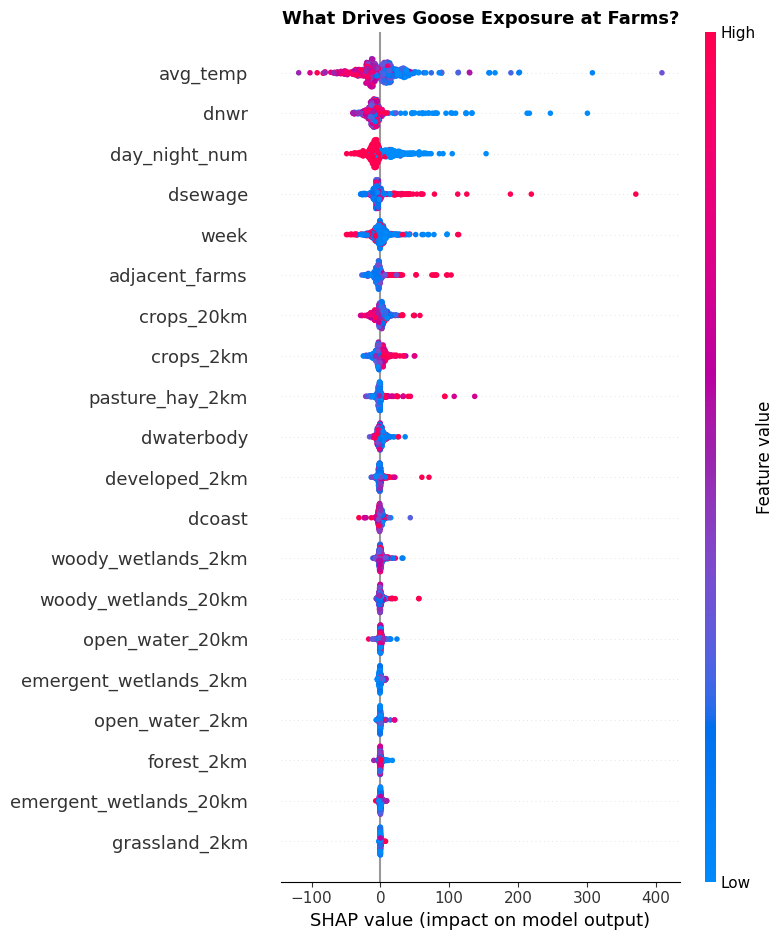

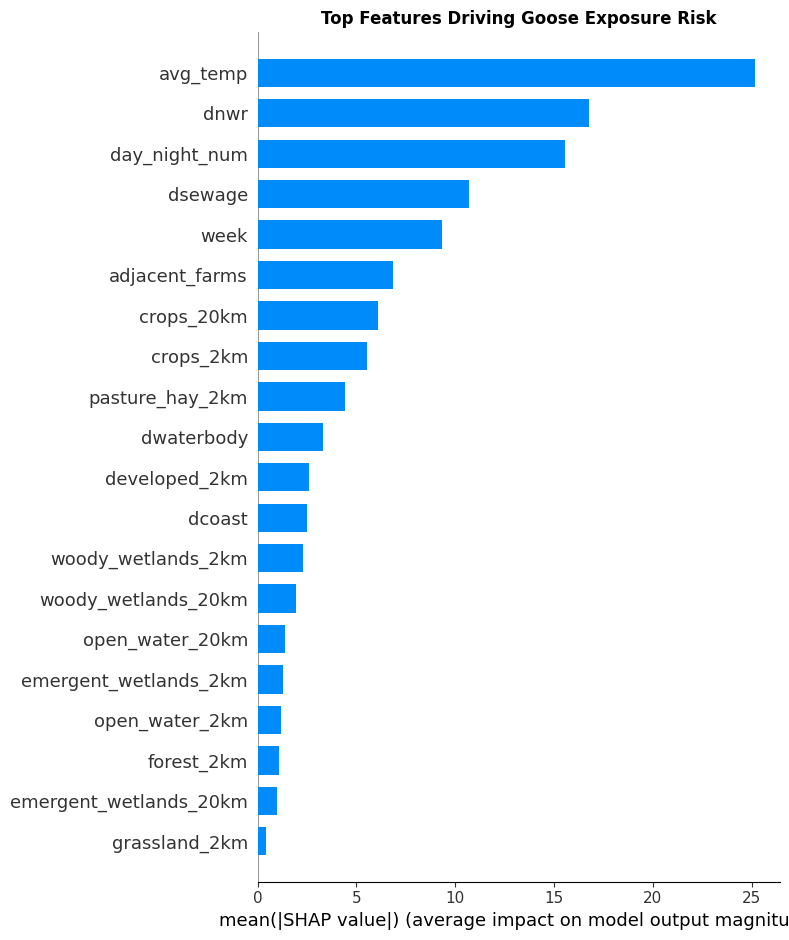

✅ SHAP plots saved!


In [26]:
import shap

print("Calculating SHAP values - 2-3 minutes...")

# Use the ORIGINAL Stage 2 regressor (reg) - it was better
# SHAP explains WHY the model makes each prediction
# Like an X-ray for our black box model
explainer = shap.TreeExplainer(reg)

# Use 500 rows sample to keep it fast
# Only from farms where geese actually showed up
X_nonzero = X_train[mask_train]
X_sample = X_nonzero.sample(500, random_state=42)

shap_values = explainer.shap_values(X_sample)

# Plot 1 - Beeswarm plot
# Each dot = one farm observation
# Red dots = high feature value, Blue = low
# Right side = increases goose exposure, Left = decreases
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample,
                  feature_names=feature_cols_clean,
                  show=False)
plt.title('What Drives Goose Exposure at Farms?',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{project_path}/plot_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2 - Bar chart (cleaner for slides)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample,
                  feature_names=feature_cols_clean,
                  plot_type='bar', show=False)
plt.title('Top Features Driving Goose Exposure Risk', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{project_path}/plot_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ SHAP plots saved!")

# Final Prediction

## 30,032 missing values willbe filled based on the information we did and gathered above.

## Best Modeling catagory

In [27]:
# Apply same cleaning to the missing data rows
# These are the rows we need to PREDICT for the competition
df_missing['day_night_num'] = df_missing['day_night'].map({'day': 1, 'night': 0})
df_missing['farm_pond_binary'] = df_missing['farm_pond_binary'].map(
    {'yes': 1, 'no': 0, 1: 1, 2: 0}
)

X_predict = df_missing[feature_cols_clean].fillna(0)

# Stage 1 - Will geese show up?
presence_preds = clf.predict(X_predict)

# Stage 2 - How many?
final_preds = np.zeros(len(X_predict))
present_mask_final = presence_preds == 1
if present_mask_final.sum() > 0:
    log_preds = np.log1p(reg.predict(X_predict[present_mask_final]))
    final_preds[present_mask_final] = np.expm1(log_preds)

# Save predictions
df_missing['predicted_points_per_hr'] = final_preds

print(f"Total predictions made: {len(df_missing):,}")
print(f"Predicted as geese present: {present_mask_final.sum():,}")
print(f"Predicted as no geese: {(~present_mask_final).sum():,}")
print(f"\nPrediction stats:")
print(df_missing['predicted_points_per_hr'].describe().round(4))

# Save to Drive
df_missing[['unique_id', 'week', 'day_night',
            'predicted_points_per_hr']].to_csv(
    f'{project_path}/final_predictions.csv', index=False
)
print(f"\n✅ Predictions saved to Drive!")

Total predictions made: 30,032
Predicted as geese present: 439
Predicted as no geese: 29,593

Prediction stats:
count    30032.0000
mean         0.9084
std         10.3541
min          0.0000
25%          0.0000
50%          0.0000
75%          0.0000
max        334.8891
Name: predicted_points_per_hr, dtype: float64

✅ Predictions saved to Drive!


# Farm Risk Score for the the Best Insight score

## We give every farm a score from 0-100 based on how likely geese are to visit it — like a credit score, but for Bird Flu risk!


In [28]:
# Farm level risk scores
farm_stats = df_known.groupby('unique_id').agg(
    avg_exposure=('points_per_hr', 'mean'),
    max_exposure=('points_per_hr', 'max'),
    nonzero_weeks=('points_per_hr', lambda x: (x > 0).sum()),
    dcoast=('dcoast', 'first'),
    dwaterbody=('dwaterbody', 'first'),
    dnwr=('dnwr', 'first'),
    adjacent_farms=('adjacent_farms', 'first'),
    open_water_2km=('open_water_2km', 'first'),
    emergent_wetlands_2km=('emergent_wetlands_2km', 'first'),
).reset_index()

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# Normalize each factor 0-1
farm_stats['norm_exposure']  = scaler.fit_transform(farm_stats[['avg_exposure']])
farm_stats['norm_max']       = scaler.fit_transform(farm_stats[['max_exposure']])
farm_stats['norm_weeks']     = scaler.fit_transform(farm_stats[['nonzero_weeks']])
farm_stats['norm_coast']     = 1 - scaler.fit_transform(farm_stats[['dcoast']])
farm_stats['norm_water']     = 1 - scaler.fit_transform(farm_stats[['dwaterbody']])
farm_stats['norm_nwr']       = scaler.fit_transform(farm_stats[['dnwr']])  # far from refuge = riskier
farm_stats['norm_adj']       = scaler.fit_transform(farm_stats[['adjacent_farms']])

# Weighted score based on SHAP importance!
farm_stats['risk_score'] = (
    farm_stats['norm_exposure'] * 0.30 +
    farm_stats['norm_max']      * 0.15 +
    farm_stats['norm_weeks']    * 0.15 +
    farm_stats['norm_nwr']      * 0.20 +  # SHAP said this matters a lot!
    farm_stats['norm_coast']    * 0.08 +
    farm_stats['norm_water']    * 0.07 +
    farm_stats['norm_adj']      * 0.05
) * 100

farm_stats['risk_category'] = pd.cut(
    farm_stats['risk_score'],
    bins=[0, 20, 40, 60, 80, 100],
    labels=['🟢 Very Low', '🟡 Low', '🟠 Medium', '🔴 High', '🚨 Critical']
)

print("Risk Category Distribution:")
print(farm_stats['risk_category'].value_counts().sort_index())
print(f"\nTop 10 Critical Farms:")
print(farm_stats.nlargest(10, 'risk_score')[
    ['unique_id','risk_score','risk_category','avg_exposure','adjacent_farms']
].to_string())

# Save risk scores
farm_stats.to_csv(f'{project_path}/farm_risk_scores.csv', index=False)
print(f"\n✅ Risk scores saved!")

Risk Category Distribution:
risk_category
🟢 Very Low    1310
🟡 Low         2122
🟠 Medium        63
🔴 High           9
🚨 Critical       0
Name: count, dtype: int64

Top 10 Critical Farms:
      unique_id  risk_score risk_category  avg_exposure  adjacent_farms
1783       3165   73.267321        🔴 High     80.352840              12
1782       3164   72.841815        🔴 High     79.064012              12
2656       4743   66.172258        🔴 High     51.810615               7
1558       2628   62.595527        🔴 High     51.760425               4
1555       2625   62.507018        🔴 High     51.938417               4
1556       2626   62.505987        🔴 High     51.980309               4
1557       2627   62.478524        🔴 High     51.951112               4
2655       4739   61.494035        🔴 High     41.580103               9
2654       4738   60.612983        🔴 High     40.628548               9
1781       3163   59.338207      🟠 Medium     60.172841              25

✅ Risk scores saved!

# visualization

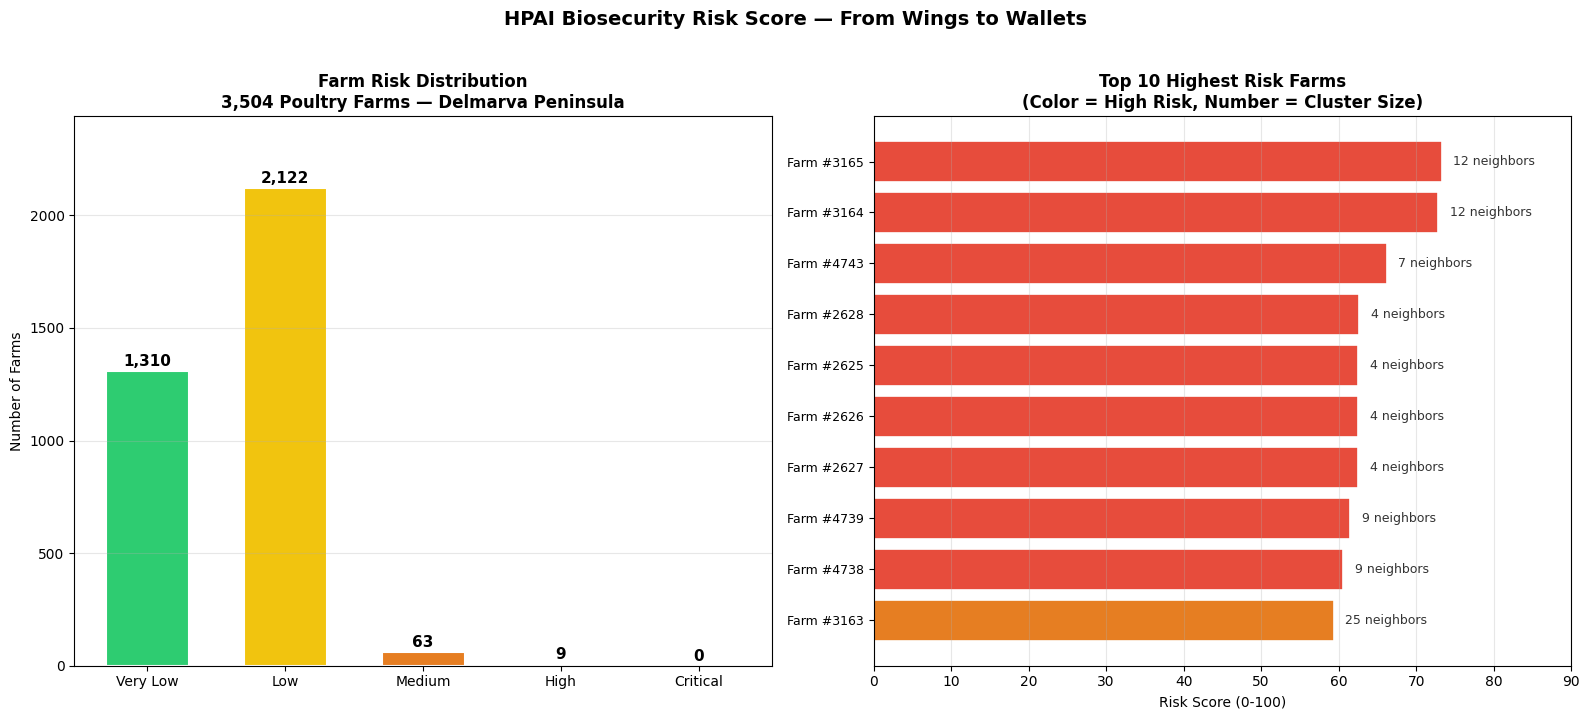

✅ Final risk plot saved!


In [29]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ---- Plot 1 - Risk Category Distribution ----
categories = ['🟢 Very Low', '🟡 Low', '🟠 Medium', '🔴 High', '🚨 Critical']
counts = [1310, 2122, 63, 9, 0]
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8e044b']

bars = axes[0].bar(range(len(categories)), counts,
                   color=colors, edgecolor='white', linewidth=1.5, width=0.6)

# Add count labels on top of bars
for bar, val in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=11)

axes[0].set_xticks(range(len(categories)))
axes[0].set_xticklabels(['Very Low', 'Low', 'Medium', 'High', 'Critical'],
                         fontsize=10)
axes[0].set_title('Farm Risk Distribution\n3,504 Poultry Farms — Delmarva Peninsula',
                   fontweight='bold', fontsize=12)
axes[0].set_ylabel('Number of Farms')
axes[0].set_ylim(0, max(counts) * 1.15)
axes[0].grid(axis='y', alpha=0.3)

# ---- Plot 2 - Top 10 Farms Risk Score ----
top10 = farm_stats.nlargest(10, 'risk_score')

# Color bars by risk score
bar_colors = ['#e74c3c' if s > 60 else '#e67e22'
              for s in top10['risk_score']]

bars2 = axes[1].barh(range(10), top10['risk_score'].values,
                     color=bar_colors, edgecolor='white', linewidth=1.2)

# Add adjacent farm count as annotation
for i, (_, row) in enumerate(top10.iterrows()):
    axes[1].text(row['risk_score'] + 0.5, i,
                 f"  {int(row['adjacent_farms'])} neighbors",
                 va='center', fontsize=9, color='#333333')

axes[1].set_yticks(range(10))
axes[1].set_yticklabels([f"Farm #{int(uid)}"
                          for uid in top10['unique_id']], fontsize=9)
axes[1].set_xlabel('Risk Score (0-100)')
axes[1].set_title('Top 10 Highest Risk Farms\n(Color = High Risk, Number = Cluster Size)',
                   fontweight='bold', fontsize=12)
axes[1].invert_yaxis()
axes[1].set_xlim(0, 90)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('HPAI Biosecurity Risk Score — From Wings to Wallets',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{project_path}/plot_final_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Final risk plot saved!")